In [1]:
%cd /content

!mkdir -p ml-assessment-shantanu-rastogi/part_a
!mkdir -p ml-assessment-shantanu-rastogi/data

%cd ml-assessment-shantanu-rastogi/part_a

/content
/content/ml-assessment-shantanu-rastogi/part_a


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
print(df.shape)

df.info()

df.head()

(500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [7]:
print(scaled_data[:5])

[[-0.72521859 -0.17615043  0.11016555 -0.26501121 -0.0899507   0.55095233]
 [-1.48846049 -1.04682639  0.48615719 -0.9804657  -0.83517593 -0.68068477]
 [ 0.17679458  0.2673371  -0.45382191 -0.23685064 -0.67404615 -0.27013907]
 [-0.72521859 -1.01230889  0.29816137 -0.82778261 -0.99630571 -1.09123047]
 [-1.48846049 -1.03448783  1.42613628 -1.00598621 -0.65390493 -1.50177617]]


### Why Scaling is Important

Scaling is necessary before K-Means because the algorithm uses distance to form clusters.

If features exist on different ranges, larger-scale variables may dominate clustering results.

Standardization ensures all features contribute fairly.

In [8]:
from sklearn.cluster import KMeans

In [9]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

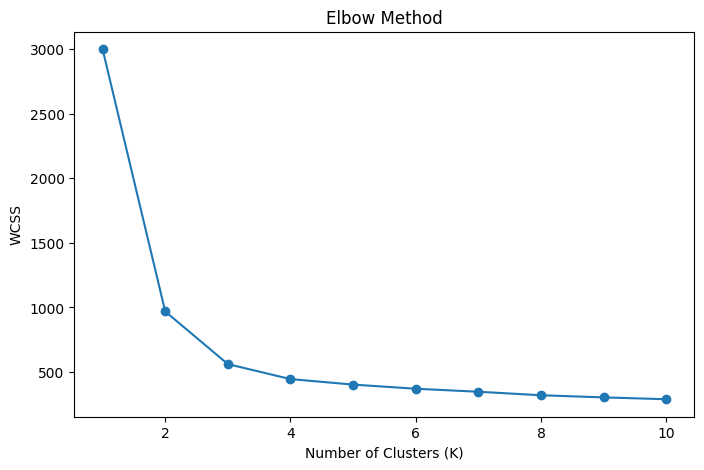

In [10]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

### Choosing Optimal K

The elbow plot suggests an optimal K value of 3.

This was selected because WCSS decreases sharply until K = 3, after which the rate of improvement slows significantly.

This indicates diminishing returns from adding additional clusters beyond 3.

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

In [12]:
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [13]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print(centroids)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


### Cluster Interpretation

Three customer segments were identified:

**Cluster 0: Frequent Low-Spenders**
- Younger customers
- Visit frequently
- Lower annual spending
- Smaller basket sizes

**Cluster 1: High-Value Occasional Shoppers**
- Older customers
- Very high annual spending
- Fewer visits
- Large basket sizes
- Purchase across many categories

**Cluster 2: Regular Mid-Value Shoppers**
- Middle-aged customers
- Moderate-to-high spending
- Moderate visit frequency
- Balanced purchasing behavior

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=df.columns[:-1]
)

print(loadings)

                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


In [17]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


### PCA Interpretation

Principal Component 1 (PC1) appears to capture customer value and purchasing intensity, driven by annual spend, basket size, and number of categories purchased.

Principal Component 2 (PC2) appears to capture customer visit behavior, particularly recency and visit frequency.

Together, these components help summarize customer differences for clustering visualization.

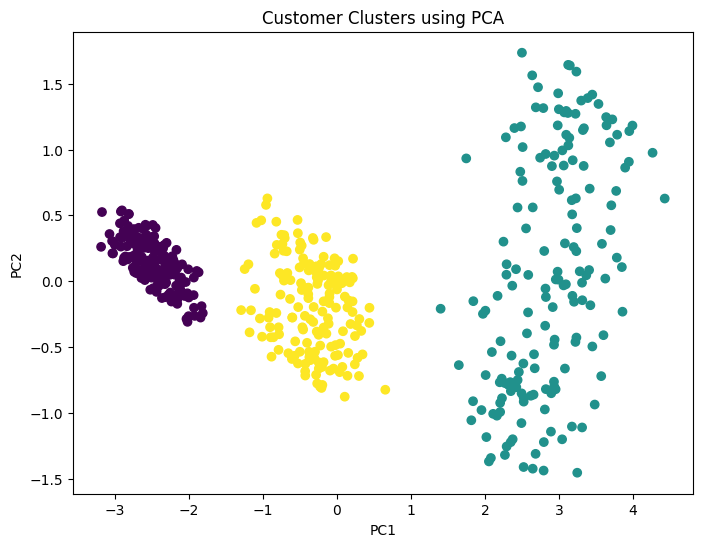

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['cluster'],
)

plt.title('Customer Clusters using PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

### Cluster Visualization

The PCA scatter plot shows clear separation among the three customer clusters.

- Cluster 0 represents a distinct group of frequent low-spenders.
- Cluster 1 represents high-value occasional shoppers.
- Cluster 2 represents regular mid-value shoppers.

The visible separation suggests the clustering solution is meaningful and captures differences in customer behavior.